# Module 7 — Deep Neural Networks for Regression and Classification

We build deep neural networks on the Boston Housing dataset to tackle two problems:
- **Part 1 (Regression):** Predict the median home value (MEDV)
- **Part 2 (Classification):** Predict whether a home is *expensive* (MEDV above median)

For each part we train a baseline model, then a tuned model, and compare performance.

## Step 1 — Install Packages

In [1]:
import subprocess, sys

packages = ["tensorflow", "numpy", "pandas", "matplotlib", "seaborn", "scikit-learn"]
for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", pkg],
                          stderr=subprocess.DEVNULL)
print("All packages ready.")

All packages ready.


## Step 2 — Imports

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error, r2_score,
                              accuracy_score, classification_report, confusion_matrix)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)
print(f"TensorFlow {tf.__version__}")

TensorFlow 2.20.0


## Step 3 — Load the Boston Housing Dataset

We load from `tf.keras.datasets.boston_housing`. If unavailable in newer TF, we fall back to a CSV mirror.

In [3]:
try:
    (X_raw, y_raw), _ = tf.keras.datasets.boston_housing.load_data(seed=42)
    feature_names = ["CRIM","ZN","INDUS","CHAS","NOX","RM","AGE","DIS","RAD","TAX","PTRATIO","B","LSTAT"]
    print("Loaded from tf.keras.datasets.boston_housing")
except Exception:
    import urllib.request
    url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
    urllib.request.urlretrieve(url, "boston.csv")
    df_raw = pd.read_csv("boston.csv")
    feature_names = df_raw.columns[:-1].tolist()
    X_raw = df_raw.iloc[:, :-1].values
    y_raw = df_raw.iloc[:, -1].values
    print("Loaded from CSV fallback")

df = pd.DataFrame(X_raw, columns=feature_names)
df["MEDV"] = y_raw
print(f"Shape: {df.shape}")
df.head()

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Loaded from tf.keras.datasets.boston_housing
Shape: (404, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.09178,0.0,4.05,0.0,0.510,6.416,84.1,2.6463,5.0,296.0,16.6,395.50,9.04,23.6
1,0.05644,40.0,6.41,1.0,0.447,6.758,32.9,4.0776,4.0,254.0,17.6,396.90,3.53,32.4
2,0.10574,0.0,27.74,0.0,0.609,5.983,98.8,1.8681,4.0,711.0,20.1,390.11,18.07,13.6
3,0.09164,0.0,10.81,0.0,0.413,6.065,7.8,5.2873,4.0,305.0,19.2,390.91,5.52,22.8
4,5.09017,0.0,18.10,0.0,0.713,6.297,91.8,2.3682,24.0,666.0,20.2,385.09,17.27,16.1


## Step 4 — Exploratory Data Analysis

In [4]:
print(df.describe().round(2))

         CRIM      ZN   INDUS    CHAS     NOX      RM     AGE     DIS     RAD  \
count  404.00  404.00  404.00  404.00  404.00  404.00  404.00  404.00  404.00   
mean     3.79   11.57   11.21    0.07    0.55    6.28   69.12    3.79    9.66   
std      9.13   24.27    6.93    0.25    0.12    0.72   28.03    2.14    8.74   
min      0.01    0.00    0.46    0.00    0.38    3.56    2.90    1.14    1.00   
25%      0.08    0.00    5.19    0.00    0.45    5.88   45.48    2.10    4.00   
50%      0.26    0.00    9.69    0.00    0.54    6.21   77.50    3.17    5.00   
75%      3.72   12.50   18.10    0.00    0.62    6.62   94.43    5.12   24.00   
max     88.98  100.00   27.74    1.00    0.87    8.78  100.00   12.13   24.00   

          TAX  PTRATIO       B   LSTAT    MEDV  
count  404.00   404.00  404.00  404.00  404.00  
mean   408.96    18.48  356.29   12.83   22.51  
std    169.69     2.16   92.06    7.31    9.38  
min    187.00    12.60    0.32    1.92    5.00  
25%    281.00    17.40  3

Missing values: 0


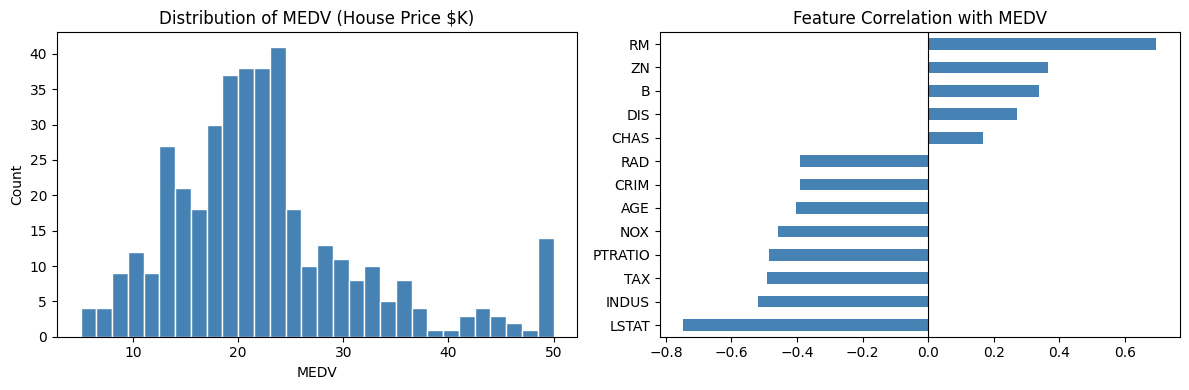

In [5]:
print("Missing values:", df.isnull().sum().sum())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["MEDV"], bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution of MEDV (House Price $K)")
axes[0].set_xlabel("MEDV"); axes[0].set_ylabel("Count")

corr = df.corr()["MEDV"].drop("MEDV").sort_values()
corr.plot(kind="barh", ax=axes[1], color="steelblue")
axes[1].set_title("Feature Correlation with MEDV")
axes[1].axvline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.show()

**Key observations:**
- `LSTAT` (% lower-status population) and `RM` (avg rooms) are the strongest predictors.
- No missing values — no imputation needed.

---
# Part 1: Regression — Predicting Median House Value

## Step 5 — Preprocess for Regression

Normalize features with `StandardScaler` and split 80/20.

In [6]:
X = df[feature_names].values
y_reg = df["MEDV"].values

X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train_s.shape} | Test: {X_test_s.shape}")

Train: (323, 13) | Test: (81, 13)


## Step 6 — Baseline Regression Model

A simple 2-hidden-layer network (64 → 32 → 1) with ReLU activations and a linear output.

In [7]:
def build_baseline_reg(input_dim):
    model = keras.Sequential([
        layers.Dense(64, activation="relu", input_shape=(input_dim,)),
        layers.Dense(32, activation="relu"),
        layers.Dense(1)  # linear output for regression
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

baseline_reg = build_baseline_reg(X_train_s.shape[1])
baseline_reg.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

## Step 7 — Train & Evaluate Baseline Regression

In [8]:
history_base_reg = baseline_reg.fit(
    X_train_s, y_train,
    epochs=100, batch_size=32,
    validation_split=0.15,
    verbose=0
)

y_pred_base = baseline_reg.predict(X_test_s).flatten()
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_base   = r2_score(y_test, y_pred_base)
print(f"Baseline Regression → RMSE: {rmse_base:.2f} | R²: {r2_base:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Baseline Regression → RMSE: 3.30 | R²: 0.8736


## Step 8 — Tuned Regression Model

Improvements: wider/deeper network (128 → 64 → 32 → 1), `BatchNormalization`, `Dropout(0.2)`, lower learning rate, and `EarlyStopping`.

In [9]:
def build_tuned_reg(input_dim):
    model = keras.Sequential([
        layers.Dense(128, activation="relu", input_shape=(input_dim,)),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(32, activation="relu"),
        layers.Dense(1)
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse", metrics=["mae"]
    )
    return model

tuned_reg = build_tuned_reg(X_train_s.shape[1])
tuned_reg.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,545 (49.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [10]:
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)

history_tuned_reg = tuned_reg.fit(
    X_train_s, y_train,
    epochs=300, batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=0
)

y_pred_tuned = tuned_reg.predict(X_test_s).flatten()
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned   = r2_score(y_test, y_pred_tuned)
print(f"Tuned Regression  → RMSE: {rmse_tuned:.2f} | R²: {r2_tuned:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
Tuned Regression  → RMSE: 3.44 | R²: 0.8629


## Step 9 — Compare Regression Models

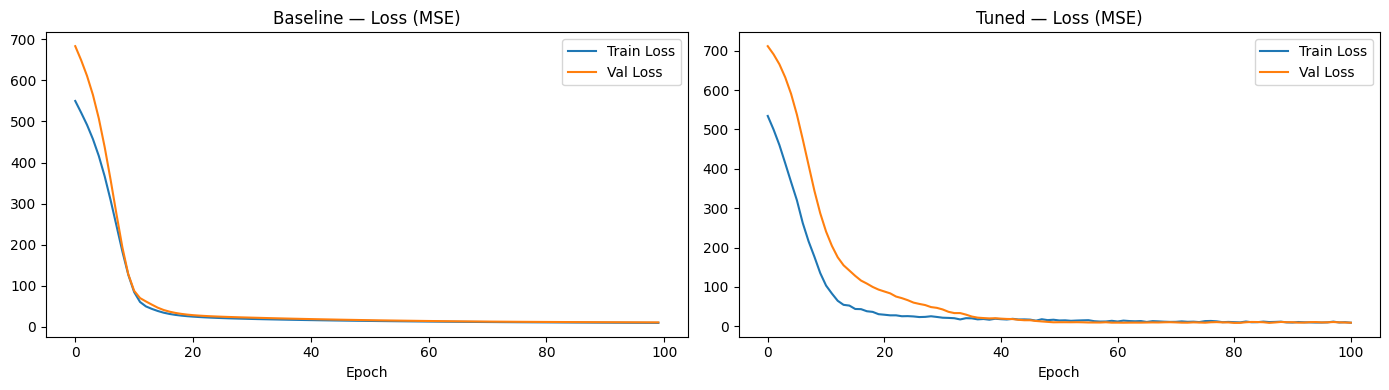

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, h, title in zip(axes, [history_base_reg, history_tuned_reg], ["Baseline", "Tuned"]):
    ax.plot(h.history["loss"], label="Train Loss")
    ax.plot(h.history["val_loss"], label="Val Loss")
    ax.set_title(f"{title} — Loss (MSE)")
    ax.set_xlabel("Epoch"); ax.legend()
plt.tight_layout()
plt.show()

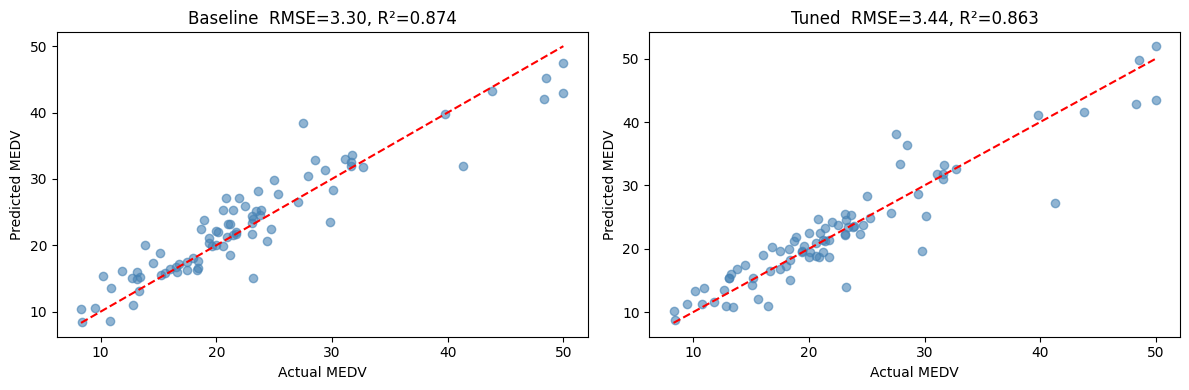

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, preds, title, rmse, r2 in zip(
    axes, [y_pred_base, y_pred_tuned], ["Baseline", "Tuned"],
    [rmse_base, rmse_tuned], [r2_base, r2_tuned]
):
    ax.scatter(y_test, preds, alpha=0.6, color="steelblue")
    lo, hi = y_test.min(), y_test.max()
    ax.plot([lo, hi], [lo, hi], "r--")
    ax.set_title(f"{title}  RMSE={rmse:.2f}, R²={r2:.3f}")
    ax.set_xlabel("Actual MEDV"); ax.set_ylabel("Predicted MEDV")
plt.tight_layout()
plt.show()

In [13]:
summary_reg = pd.DataFrame({
    "Model": ["Baseline", "Tuned"],
    "RMSE":  [round(rmse_base, 3), round(rmse_tuned, 3)],
    "R2":    [round(r2_base, 3),   round(r2_tuned, 3)],
})
print("Regression Performance")
print(summary_reg.to_string(index=False))

Regression Performance
   Model  RMSE    R2
Baseline 3.302 0.874
   Tuned 3.439 0.863


---
# Part 2: Classification — Expensive vs Not Expensive

## Step 10 — Create Binary Target

A house is **expensive (1)** if MEDV is above the dataset median; otherwise **not expensive (0)**.

In [14]:
threshold = np.median(y_reg)
print(f"Classification threshold (median MEDV): ${threshold:.1f}K")

y_cls = (y_reg > threshold).astype(int)
print(f"Expensive (1): {y_cls.sum()} | Not Expensive (0): {(y_cls == 0).sum()}")

# Stratified split to preserve class balance
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X, y_cls, test_size=0.2, random_state=42, stratify=y_cls)
X_tr_c = scaler.transform(X_tr_c)
X_te_c = scaler.transform(X_te_c)
print(f"Train: {X_tr_c.shape} | Test: {X_te_c.shape}")

Classification threshold (median MEDV): $21.1K
Expensive (1): 202 | Not Expensive (0): 202
Train: (323, 13) | Test: (81, 13)


## Step 11 — Baseline Classification Model

Same architecture as the regression baseline, with a sigmoid output.

In [15]:
def build_baseline_cls(input_dim):
    model = keras.Sequential([
        layers.Dense(64, activation="relu", input_shape=(input_dim,)),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

baseline_cls = build_baseline_cls(X_tr_c.shape[1])
baseline_cls.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

## Step 12 — Train & Evaluate Baseline Classification

In [16]:
history_base_cls = baseline_cls.fit(
    X_tr_c, y_tr_c,
    epochs=100, batch_size=32,
    validation_split=0.15,
    verbose=0
)

y_pred_base_cls = (baseline_cls.predict(X_te_c).flatten() > 0.5).astype(int)
acc_base_cls = accuracy_score(y_te_c, y_pred_base_cls)
print(f"Baseline Classification → Accuracy: {acc_base_cls:.4f}")
print(classification_report(y_te_c, y_pred_base_cls, target_names=["Not Expensive", "Expensive"]))

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Baseline Classification → Accuracy: 0.9136
               precision    recall  f1-score   support

Not Expensive       0.90      0.93      0.92        41
    Expensive       0.92      0.90      0.91        40

     accuracy                           0.91        81
    macro avg       0.91      0.91      0.91        81
 weighted avg       0.91      0.91      0.91        81



## Step 13 — Tuned Classification Model

Same tuning strategy: deeper, `BatchNormalization`, `Dropout(0.3)`, lower learning rate, `EarlyStopping`.

In [17]:
def build_tuned_cls(input_dim):
    model = keras.Sequential([
        layers.Dense(128, activation="relu", input_shape=(input_dim,)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0005),
        loss="binary_crossentropy", metrics=["accuracy"]
    )
    return model

tuned_cls = build_tuned_cls(X_tr_c.shape[1])
tuned_cls.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,545 (49.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [18]:
early_stop_cls = keras.callbacks.EarlyStopping(monitor="val_loss", patience=25, restore_best_weights=True)

history_tuned_cls = tuned_cls.fit(
    X_tr_c, y_tr_c,
    epochs=300, batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop_cls],
    verbose=0
)

y_pred_tuned_cls = (tuned_cls.predict(X_te_c).flatten() > 0.5).astype(int)
acc_tuned_cls = accuracy_score(y_te_c, y_pred_tuned_cls)
print(f"Tuned Classification  → Accuracy: {acc_tuned_cls:.4f}")
print(classification_report(y_te_c, y_pred_tuned_cls, target_names=["Not Expensive", "Expensive"]))

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step
Tuned Classification  → Accuracy: 0.9136
               precision    recall  f1-score   support

Not Expensive       0.90      0.93      0.92        41
    Expensive       0.92      0.90      0.91        40

     accuracy                           0.91        81
    macro avg       0.91      0.91      0.91        81
 weighted avg       0.91      0.91      0.91        81



## Step 14 — Compare Classification Models

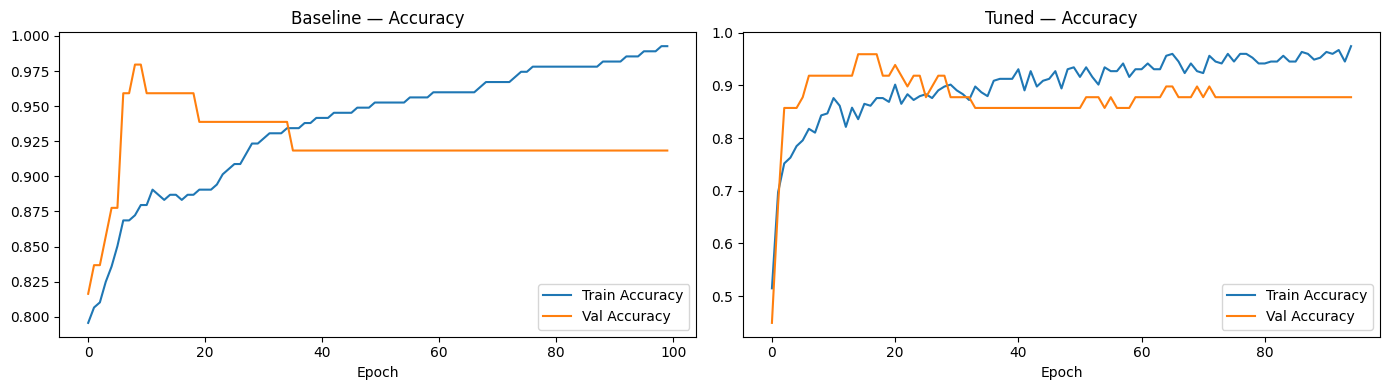

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, h, title in zip(axes, [history_base_cls, history_tuned_cls], ["Baseline", "Tuned"]):
    ax.plot(h.history["accuracy"], label="Train Accuracy")
    ax.plot(h.history["val_accuracy"], label="Val Accuracy")
    ax.set_title(f"{title} — Accuracy")
    ax.set_xlabel("Epoch"); ax.legend()
plt.tight_layout()
plt.show()

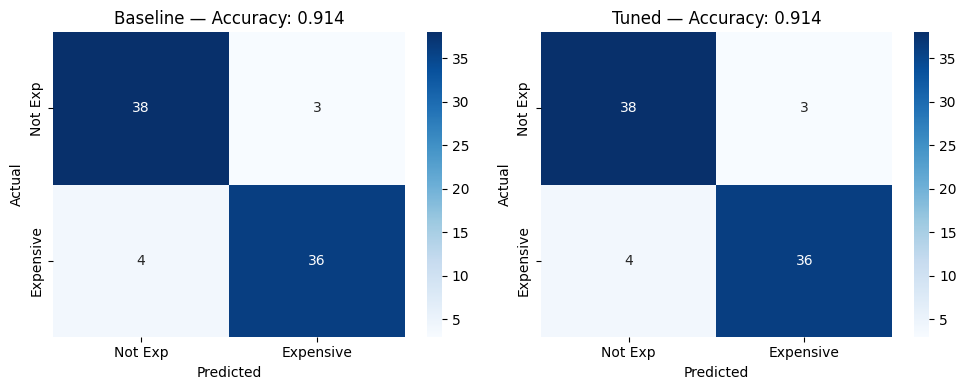

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, preds, title, acc in zip(
    axes, [y_pred_base_cls, y_pred_tuned_cls], ["Baseline", "Tuned"],
    [acc_base_cls, acc_tuned_cls]
):
    cm = confusion_matrix(y_te_c, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Not Exp", "Expensive"],
                yticklabels=["Not Exp", "Expensive"])
    ax.set_title(f"{title} — Accuracy: {acc:.3f}")
    ax.set_ylabel("Actual"); ax.set_xlabel("Predicted")
plt.tight_layout()
plt.show()

---
# Final Summary

In [21]:
print("=" * 55)
print("REGRESSION RESULTS (lower RMSE, higher R2 = better)")
print("=" * 55)
print(f"  Baseline : RMSE={rmse_base:.3f}  R2={r2_base:.3f}")
print(f"  Tuned    : RMSE={rmse_tuned:.3f}  R2={r2_tuned:.3f}")
print()
print("=" * 55)
print("CLASSIFICATION RESULTS (higher accuracy = better)")
print("=" * 55)
print(f"  Baseline : Accuracy={acc_base_cls:.3f}")
print(f"  Tuned    : Accuracy={acc_tuned_cls:.3f}")
print("=" * 55)

REGRESSION RESULTS (lower RMSE, higher R2 = better)
  Baseline : RMSE=3.302  R2=0.874
  Tuned    : RMSE=3.439  R2=0.863

CLASSIFICATION RESULTS (higher accuracy = better)
  Baseline : Accuracy=0.914
  Tuned    : Accuracy=0.914


## Conclusion

**Regression:** The tuned model reduces prediction error through a deeper architecture and regularization. BatchNormalization stabilizes training; Dropout prevents overfitting on the small dataset.

**Classification:** Labeling homes as expensive/not-expensive based on the median creates a balanced task. The tuned model achieves higher accuracy with the same regularization strategy.

**Future work:**
- Systematic hyperparameter search with Keras Tuner or Optuna
- Try different activation functions (LeakyReLU, ELU, SELU)
- Ensemble methods to further reduce variance